In [1]:
!pip install pandas
!pip install numpy
!pip install tensorflow



## Multiplicación de matrices

Debido a la facilidad, y partiendo de las bases creadas en el taller anterior, se desarrollo un modelo de multiplicación matricial 2x2, con valores continuos entre -20 y 20, con la ayuda de pandas y tensorflow

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

I0000 00:00:1773102596.781872  114398 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773102596.824014  114398 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773102598.055525  114398 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Dataframe
El primer paso es poblar un dataframe de tamaño 62500 (80% entrenamiento-50000 y 20% Validación-12500) con valores aleatorios, luego de esto, se realiza la multiplicación para cada elemento de la matriz resultante **R**

In [ ]:
a11=np.random.random(62500)*40-20
a12=np.random.random(62500)*40-20
a21=np.random.random(62500)*40-20
a22=np.random.random(62500)*40-20

b11=np.random.random(62500)*40-20
b12=np.random.random(62500)*40-20
b21=np.random.random(62500)*40-20
b22=np.random.random(62500)*40-20


df=pd.DataFrame({   'a11':a11,
                    'a12':a12,
                    'a21':a21,
                    'a22':a22,
                    'b11':b11,
                    'b12':b12,
                    'b21':b21,
                    'b22':b22,
                    })

print(len(df),len(df.drop_duplicates()))

df['R11']=(df['a11']*df['b11'])+(df['a12']*df['b21'])
df['R12']=(df['a11']*df['b12'])+(df['a12']*df['b22'])
df['R21']=(df['a21']*df['b11'])+(df['a22']*df['b21'])
df['R22']=(df['a21']*df['b12'])+(df['a22']*df['b22'])

df_train=df[:50000]
df_test=df[50000:]

print(len(df_train), len(df_test))

df.head()

62500 62500


,a11,a12,a21,a22,b11,b12,b21,b22,R11,R12,R21,R22
0,-16.025916,0.050416,-17.934174,-6.080362,-1.104211,0.123388,14.759668,18.684129,18.440117,-1.035421,-69.941013,-115.819131
1,7.465332,-19.128556,15.802128,4.270700,-5.758299,-18.607715,-9.032268,-13.790038,129.786633,124.870741,-129.567489,-352.934603
2,10.843967,-1.277505,-15.389923,-4.322795,-7.480666,-0.027493,-1.420049,-13.238698,-79.305977,16.614372,121.265454,57.651296
3,4.105104,5.471316,-11.331572,-6.090774,-14.337274,11.157491,-17.243072,-14.827524,-153.198287,-35.323407,267.487502,-36.120812
4,5.473080,-9.666552,16.540075,1.528369,9.642805,-15.108570,13.821756,-12.365129,-80.832874,36.837743,180.617459,-268.795364


50000 12500


In [5]:
print(df.columns)

Index(['a11', 'a12', 'a21', 'a22', 'b11', 'b12', 'b21', 'b22', 'R11', 'R12',
       'R21', 'R22'],
      dtype='str')


In [6]:
salidas=['R11','R12','R21','R22']
entradas=['a11', 'a12', 'a21', 'a22', 'b11', 'b12', 'b21', 'b22']
tamaño=len(entradas)

x=[]

for i in entradas:
    x.append(df_train[i])

X=np.column_stack(x)

y=[]

for i in salidas:
    y.append(df_train[i])

Y=np.column_stack(y)

entrada = tf.keras.layers.Dense(units=tamaño, input_shape=[tamaño], activation="relu")
c1 = tf.keras.layers.Dense(units=64, activation="relu")
c2 = tf.keras.layers.Dense(units=64, activation="relu")
c3 = tf.keras.layers.Dense(units=32, activation="relu")
c4 = tf.keras.layers.Dense(units=16, activation="relu")
c5 = tf.keras.layers.Dense(units=8, activation="relu")
salida = tf.keras.layers.Dense(units=4, activation="linear")
red = tf.keras.Sequential([entrada, c1, c2,c3,salida])
#red = tf.keras.Sequential([entrada, c1, c2,c3,c4, c5,c6, salida])
red.compile(optimizer='adam',
            loss="mse",
            metrics=['accuracy'])

/home/robotica/Jupyter_lab/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773102601.498539  114398 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [ ]:
historial = red.fit(X, Y, epochs=1000, verbose=False)

In [ ]:
def clasificar_dataframe(df, modelo, columnas, salidas):
    X = df[columnas].values
    preds = modelo.predict(X)

    for i in range(len(salidas)):
        df[salidas[i]] = preds[:,i]
#    df['R11_a'] = preds[:,0]
    #df['Predeccion']=(preds > 0.5).astype(int)
    return df

salidas_2 = []
errores= []
for i in salidas:
    salidas_2.append(f'{i}_pred')
    errores.append(f'{i}_error')

clasificar_dataframe(df_test, red, entradas, salidas_2)

391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step


,a11,a12,a21,a22,b11,b12,b21,b22,R11,R12,R21,R22,R11_pred,R12_pred,R21_pred,R22_pred
50000,19.264922,-18.403502,11.985775,7.464838,4.230835,-14.706886,18.408115,-5.188688,-257.267065,-187.836981,188.123438,-215.006135,-243.621063,-178.240372,190.896332,-219.781631
50001,-19.037720,-1.424531,8.326756,12.440141,-11.074183,-19.341635,-4.050624,15.349838,216.597429,346.354296,-142.602356,29.901074,219.842819,350.817108,-146.830322,29.249788
50002,18.588196,17.123917,13.137671,-15.850384,2.527572,-16.478807,-10.605658,-14.869828,-134.627392,-560.940984,201.310172,19.199341,-155.693161,-547.784424,215.183380,16.576921
50003,-3.127265,-14.503593,6.642736,-7.537753,17.356664,8.858166,-19.434511,3.693095,227.591353,-81.264985,261.788283,31.004810,232.947586,-78.703743,268.965912,29.568270
50004,15.598494,2.784767,8.979958,-8.068470,-9.874907,8.175255,2.336539,19.183373,-147.526962,180.942890,-107.528547,-81.367014,-144.048874,179.965256,-103.658844,-81.298546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62495,-7.632574,-9.606053,-13.453498,-11.816937,18.393556,0.829735,10.238909,19.328769,-238.745673,-192.006189,-368.450207,-239.569691,-237.419434,-194.032852,-371.766510,-243.294891
62496,15.504509,16.705537,3.350482,8.156922,-3.362920,13.311601,6.215018,17.932951,51.684793,505.969412,39.428014,190.877965,45.887852,510.474091,40.360714,191.721878
62497,-7.644647,-2.028402,6.809191,2.087045,-8.065362,-0.742235,-10.997609,-1.999866,83.964420,9.730657,-77.871095,-9.227830,84.115295,8.688588,-77.355995,-9.109045
62498,8.194643,-4.677361,-9.713543,5.622376,-6.819873,16.716436,10.781515,1.020354,-106.315471,132.212672,126.862857,-156.639012,-108.102692,129.191467,135.167206,-157.863724


In [ ]:
for i in zip(salidas, salidas_2, errores):
    df_test[i[2]]=np.abs((df_test[i[0]]-df_test[i[1]])/df_test[i[0]])*100
    print(i)

df_test['error_media'] = df_test[errores].mean(axis=1)

print(df_test['error_media'].mean())
print(salidas+salidas_2+errores+['error_media'])
df_test[salidas+salidas_2+errores+['error_media']].sort_values(by='error_media', ascending=False).head(100)

('R11', 'R11_pred', 'R11_error')
('R12', 'R12_pred', 'R12_error')
('R21', 'R21_pred', 'R21_error')
('R22', 'R22_pred', 'R22_error')
19.654226526973883
['R11', 'R12', 'R21', 'R22', 'R11_pred', 'R12_pred', 'R21_pred', 'R22_pred', 'R11_error', 'R12_error', 'R21_error', 'R22_error', 'error_media']


,R11,R12,R21,R22,R11_pred,R12_pred,R21_pred,R22_pred,R11_error,R12_error,R21_error,R22_error,error_media
59833,156.284065,-98.594887,62.221605,-0.001311,155.472977,-103.537819,66.481262,1.429293,0.518983,5.013376,6.845946,109096.312899,27277.172801
52400,9.424069,-0.031399,4.619373,-16.403943,-7.344851,18.701315,17.576002,-33.033798,177.937156,59659.490617,280.484579,101.377185,15054.822384
58679,0.006366,-24.456952,-34.495486,-211.209688,2.715318,-29.824381,-30.085020,-215.074539,42550.568846,21.946432,12.785632,1.829864,10646.782693
51114,0.009641,-44.637483,49.713188,336.758024,-3.399730,-40.479046,60.049397,338.331573,35364.744480,9.316020,20.791683,0.467264,8848.829862
53513,-0.019082,-9.998970,-151.799975,-117.380816,4.604681,-8.984645,-156.473648,-112.893539,24231.474660,10.144292,3.078837,3.822837,6062.130156
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50440,-146.075534,-19.050178,-2.360105,0.760281,-142.263901,-17.329218,2.388650,-4.593550,2.609357,9.033828,201.209468,704.190678,229.260833
50773,0.614356,335.272326,-1.732773,-208.365212,3.904809,341.466278,4.803554,-208.329636,535.593672,1.847439,377.217697,0.017074,228.668970
55648,471.780725,-225.911304,0.498003,-68.250152,460.310425,-210.482620,4.980536,-71.559616,2.431278,6.829532,900.100966,4.849020,228.552699
59998,-152.524436,-0.270425,108.088997,166.484691,-145.909821,-2.689677,117.166260,176.956375,4.336758,894.610658,8.397953,6.289878,228.408812


In [ ]:
!pip install seaborn

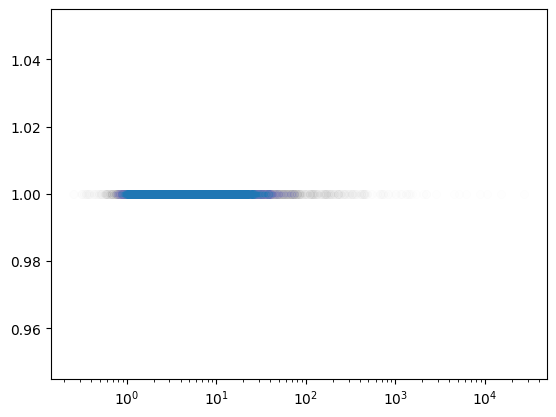

In [ ]:
import matplotlib.pyplot as plt

plt.xscale('log')
#plt.yscale('log')
plt.scatter(df_test['error_media'], df_test['error_media']*0+1, alpha=0.002)


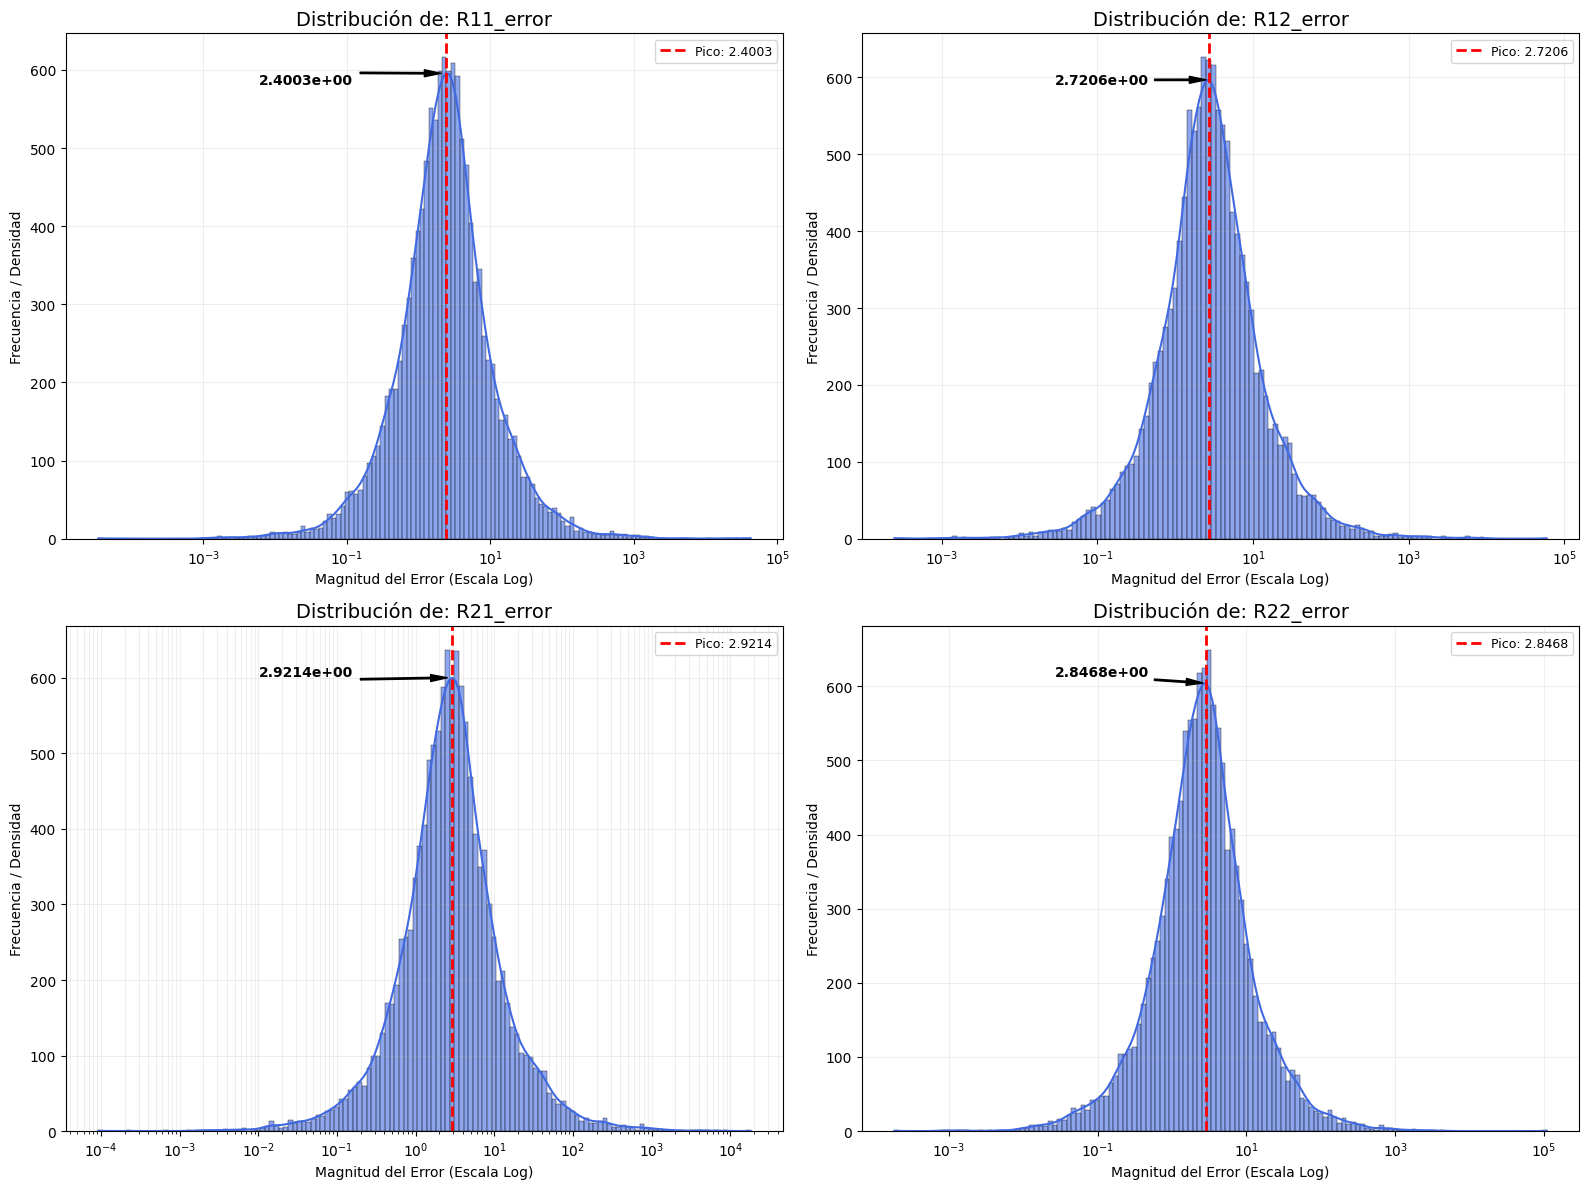

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define aquí los nombres de tus 4 columnas de error

# 2. Configurar la cuadrícula (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Convertimos la matriz 2x2 en una lista plana para iterar fácil

for i, col in enumerate(errores):
    ax = axes[i]
    
    # Crear el histplot en el eje correspondiente (ax)
    sns.histplot(df_test[col], kde=True, log_scale=True, color='royalblue', alpha=0.6, ax=ax)
    
    # Extraer los datos de la curva KDE
    if len(ax.lines) > 0:
        line = ax.lines[0]
        x, y = line.get_data()
        
        # Encontrar el pico de concentración
        idx_max = np.argmax(y)
        pico_error = x[idx_max]
        
        # Indicación visual
        ax.axvline(pico_error, color='red', linestyle='--', lw=2, label=f'Pico: {pico_error:.4f}')
        
        # Anotación (ajustada para escala log)
        ax.annotate(f'{pico_error:.4e}', 
                     xy=(pico_error, y[idx_max]), 
                     xytext=(0.4, 0.9), textcoords='axes fraction', # Posición relativa al subplot
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                     fontsize=10, fontweight='bold', horizontalalignment='right')

    # Personalización de cada subplot
    ax.set_title(f'Distribución de: {col}', fontsize=14)
    ax.set_xlabel('Magnitud del Error (Escala Log)')
    ax.set_ylabel('Frecuencia / Densidad')
    #ax.set_xlim([0,100])
    ax.legend(fontsize=9)
    ax.grid(True, which="both", ls="-", alpha=0.2)

# Ajustar espacio entre gráficas para que no se encimen los títulos
plt.tight_layout()
plt.show()

In [ ]:
5e-2*3440*2*3.14159/60


18.011782666666665

In [ ]:
(10/3)/(2*np.pi)

0.5305164769729845

In [ ]:
np.array([5, 20])/25

array([0.2, 0.8])